# Perform EDA to understand user-item interactions.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load cleaned dataset
df = pd.read_csv("cleaned_amazon_reviews.csv")

print("\n Dataset Shape:", df.shape)
print(df.head())
print(df.info())



 Dataset Shape: (8, 19)
   review_id  user_id  product_id     category subcategory  rating  \
0          1     8270      858994  Electronics      Mobile       1   
1          2     1860      749714       Beauty      Action       1   
2          3     6390      688315         Home    Clothing       1   
3          4     6191      551122      Fashion    Clothing       3   
4          6     7265      192601  Electronics     Fiction       2   

                          review_text            timestamp    price  brand  \
0                 Average experience.  2023-01-01 00:00:00  1321.10   Nike   
1              Exceeded expectations!  2023-01-01 01:00:00  1775.14   Nike   
2                Not worth the money.  2023-01-01 02:00:00   924.48   Dell   
3                 Very disappointing.  2023-01-01 03:00:00  2950.09   Nike   
4  Fantastic product! Will buy again.  2023-01-01 05:00:00  3831.15  Apple   

   helpful_votes verified_purchase sentiment    country        product_title  \
0    

In [8]:
# 1. Basic Statistics
# ---------------------------------------------
print("\n Rating Description:")
print(df["rating"].describe())

print("\n Number of Unique Users:", df["userID"].nunique() if "userID" in df.columns else "userID not found")
print(" Number of Unique Products:", df["productID"].nunique() if "productID" in df.columns else "productID not found")


 Rating Description:
count    8.00000
mean     2.00000
std      0.92582
min      1.00000
25%      1.00000
50%      2.00000
75%      3.00000
max      3.00000
Name: rating, dtype: float64

 Number of Unique Users: userID not found
 Number of Unique Products: productID not found


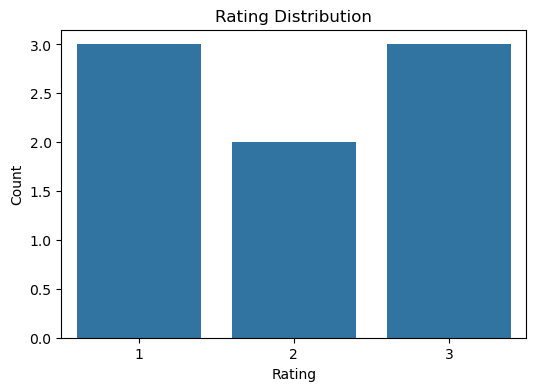

In [10]:
# 2. Rating Distribution
# ---------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x=df["rating"])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [12]:
# 3. Users with Most Ratings

if "userID" in df.columns:
    top_users = df["userID"].value_counts().head(10)
    print("\n Top 10 Active Users:")
    print(top_users)

    plt.figure(figsize=(8,4))
    top_users.plot(kind="bar")
    plt.title("Top 10 Users With Most Ratings")
    plt.ylabel("Number of Ratings")
    plt.show()

In [28]:
# 4. Products with Most Ratings

if "productID" in df.columns:
    top_products = df["productID"].value_counts().head(10)
    print("\n Top 10 Rated Products:")
    print(top_products)

    plt.figure(figsize=(8,4))
    top_products.plot(kind="bar", color="green")
    plt.title("Top 10 Products With Most Ratings")
    plt.ylabel("Number of Ratings")
    plt.show()

In [30]:
# 5. User–Item Interaction Matrix (Sparsity)

if "userID" in df.columns and "productID" in df.columns:
    user_item_matrix = df.pivot_table(index="userID", columns="productID", values="rating")
    sparsity = 1.0 - (user_item_matrix.count().sum() / user_item_matrix.size)
    print(f"\n Sparsity of Interaction Matrix: {sparsity*100:.2f}%")


In [32]:
# 6. Average Rating per Product

if "productID" in df.columns:
    product_avg = df.groupby("productID")["rating"].mean().sort_values(ascending=False).head(10)
    print("\n Top 10 Highest Rated Products:")
    print(product_avg)

    plt.figure(figsize=(8,4))
    product_avg.plot(kind="bar", color="purple")
    plt.title("Top 10 Highest Rated Products")
    plt.ylabel("Average Rating")
    plt.show()

In [34]:
# 7. Average Rating per User

if "userID" in df.columns:
    user_avg = df.groupby("userID")["rating"].mean().head(10)
    print("\n Average Rating Given by Top Users:")
    print(user_avg)